# Matching and comparison of the database with external sources

In [2]:
%load_ext autoreload
%autoreload 2

In [32]:
import pandas as pd
from copy import deepcopy as dc
import matplotlib.pyplot as plt

import os
import sys
import datetime
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.data import *
from src.data_format import format_output
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *
from src.data_format import format_output, LIST_COLS

path_save_fig = DATA_FIGURE / "validation_external_sources"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# 200 reports
# res_name_llm = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
# res_name_llm = "filtered_post_processed_geocoded_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225"
# res_name_llm = "merged_subtypespost_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
# res_name_llm = "merged_subtypespost_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_v120226_geo"
# res_name_llm = "post_processed_0-350_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v200426_v210426_geo"
# res_name_llm = "post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v230426_geo"
# res_name_llm = "post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v240426_v240426_geo"
res_name_llm = "filter_merged_post_processed_0-778_llm_response_preproc_text_sel_gaps_combined_v300626_v060726_2016-2025_meta-llama_llama-4-scout-17b-16e-instruct_v060726_v080726_geo"

cols = [
    "appealCode",
    "reportDate",
    "impactSubtype",
    "impactValue",
    "impactValueMin",
    "impactValueMax",
    "impactValuePrecision",
    "impactUnit",
    "valueAnnotation",
    "location",
    "locationAnnotation",
    "locationPolygon",
    "locationLowestAdmin",
    "country_robust_iso3",
    "hazards",
    'startYear',
    'startMonth',
    'startDay',
    'endYear',
    'endMonth',
    'endDay'
]
# df_llm_all_geo = pd.read_parquet(DATA_OUT_PROC/(res_name_llm+'.parquet'), columns=cols)
df_llm_all = pd.read_parquet(os.path.join(DATA_OUT_PROC, res_name_llm+'.parquet'))
df_llm_all = df_llm_all.drop(columns=["geometry"])
# df_llm_all = format_output(df_llm_all, list_cols=LIST_COLS+["country_robust_iso3"])
# df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'_geo_v191225.gpkg'))

# col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
# df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

# col_to_list = ["location", "locationPolygon", "iso3_code", "hazards"]
# df_llm_all_geo[col_to_list] = df_llm_all_geo[col_to_list].map(lambda x: listify_strings(x))

In [12]:
df_llm_all.appealCode.nunique()

776

In [4]:
df_llm_all_geo_grp = clean_group(df_llm_all, ADM_min=0)

In [5]:
# Import data from other sources
df_ifrc_go = open_clean_ifrc_go()
df_ifrc_go_2016 = df_ifrc_go[df_ifrc_go.appeals_start_date > '2016-01-01']
# df_ifrc_monty = open_clean_ifrc_monty(df_ifrc_go)
df_em_dat = open_emdat()

df_external_source = {}
df_external_source["IFRCGO"] = df_ifrc_go
# df_external_source["ifrc_monty"] = df_ifrc_monty
df_external_source["EMDAT"] = df_em_dat

In [8]:
df_llm_all_geo_grp_linked = {}

# # MATCHING WITH IFRC MONTY
# df_ifrc_monty_subset = df_ifrc_monty[["appealCode", "impact_type", "impact_value", "impact_category"]]
# df_llm_all_geo_grp_linked["ifrc_monty"] = df_llm_all_geo_grp.merge(df_ifrc_monty_subset, left_on=["appealCode", "impactSubtype"], right_on=["appealCode", "impact_type"])

# IFRCGO
df_ifrc_go_clean = clean_structure_ifrc_go(df_ifrc_go)
df_llm_all_geo_grp_linked["IFRCGO"] = df_llm_all_geo_grp.merge(
    df_ifrc_go_clean,
    left_on=["appealCode", "impactSubtype"],
    right_on=["IFRCGO_appealCode", "IFRCGO_impactSubtype"],
    how="left",
)

# Build long-format EMDAT impacts
df_em_dat_clean = clean_structure_emdat(df_em_dat)
df_em_dat_clean.head()

# MATCHING WITH EMDAT
months = 3
date_diff_th = datetime.timedelta(days=months*30)
df_llm_all_geo_linked, df_llm_em_dat = matching_emdat(
    df_llm_all_geo_grp,
    df_em_dat_clean,
    date_diff_th,
    "date_diff_start",
    country_field='country_iso3',
)
df_llm_all_geo_grp_linked["EMDAT"] = df_llm_all_geo_linked

# Combined linked dataframe with both EMDAT and IFRCGO matched columns
ifrc_cols = [c for c in df_llm_all_geo_grp_linked["IFRCGO"].columns if c.startswith("IFRCGO_")]
df_llm_all_linked = df_llm_all_geo_grp_linked["EMDAT"].merge(
    df_llm_all_geo_grp_linked["IFRCGO"][["appealCode", "impactSubtype"] + ifrc_cols].drop_duplicates(),
    on=["appealCode", "impactSubtype"],
    how="left",
)
df_llm_all_geo_grp_linked["ALL"] = df_llm_all_linked

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\external_comparaison.py:481: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: choose_unique_disno(x, column_minimize))


In [9]:
print("Number of IFRCGO events extracted : ", df_ifrc_go.appealCode.nunique())
print("Number of IFRCGO events extracted after 2016 : ", df_ifrc_go_2016.appealCode.nunique())
print("Number of unique appeal codes in IFRCGO linked dataframe:", df_llm_all_geo_grp_linked["IFRCGO"].IFRCGO_appealCode.nunique())

Number of IFRCGO events extracted :  2728
Number of IFRCGO events extracted after 2016 :  688
Number of unique appeal codes in IFRCGO linked dataframe: 346


In [10]:
# Look for the appeals which are in ROUGE (df_llm_all_geo_grp) but not in df_ifrc_go_2016
appeal_in_rouge = df_llm_all.appealCode.unique()
appeal_in_ifrc_go_2016 = df_ifrc_go_2016.appealCode.unique()
appeal_diff_rouge = set(appeal_in_rouge) - set(appeal_in_ifrc_go_2016)
print("Number of appeals in ROUGE but not in IFRCGO after 2016:", len(appeal_diff_rouge))
appeal_diff_ifrcgo = set(appeal_in_ifrc_go_2016) - set(appeal_in_rouge)
print("Number of appeals in IFRCGO after 2016 but not in ROUGE:", len(appeal_diff_ifrcgo))
print("Number of appeals both in ROUGE and IFRCGO after 2016:", len(set(appeal_in_rouge).intersection(set(appeal_in_ifrc_go_2016))))

Number of appeals in ROUGE but not in IFRCGO after 2016: 176
Number of appeals in IFRCGO after 2016 but not in ROUGE: 88
Number of appeals both in ROUGE and IFRCGO after 2016: 600


# Global plots

Need to plot informations about the raw dataset, such as : 
- Map with the number of event per country --> Need to filter over the same period 
- Total number of affected people (per year per country ?)
- % of reports for which we have information about each Impact Category (before matching with the ones extracted with LLM)

In [13]:
impact_subtypes = list(mapping_impact_type.keys())

### Plot of % of reports with impact information 

In [14]:
# Build counts/% for ROUGE + linked IFRCGO + linked EMDAT
impact_subtypes_input = list(mapping_impact_type.keys())

linked_sources_cfg = {
    "IFRCGO": {
        "df": df_llm_all_geo_grp_linked["IFRCGO"],
        "value_col": "IFRCGO_impactValue",
        "source_subtype_col": "IFRCGO_impactSubtype",
    },
    "EMDAT": {
        "df": df_llm_all_geo_grp_linked["EMDAT"],
        "value_col": "EMDAT_impactValue",
        "source_subtype_col": "EMDAT_ImpactSubtype",
    },
}

impact_count_summary, nb_report_with_impact, perc_report_with_impact = count_impacts_by_subtype(
    df_rouge=df_llm_all,#df_llm_all_geo_grp,
    linked_sources=linked_sources_cfg,
    impact_subtypes=impact_subtypes_input,
    rouge_value_col="impactValue",
)

In [15]:
impact_count_summary

,impactSubtype,ROUGE_count,ROUGE_perc,IFRCGO_count,IFRCGO_perc,EMDAT_count,EMDAT_perc
0,Affected People,747,96.262887,322,41.927083,501,65.234375
1,Injured People,218,28.092784,104,13.541667,124,16.145833
2,Displaced People,429,55.283505,169,22.005208,0,0.000000
3,Human Deaths,416,53.608247,195,25.390625,299,38.932292
4,Missing People,128,16.494845,54,7.031250,0,0.000000
5,Homeless People,226,29.123711,0,0.000000,17,2.213542


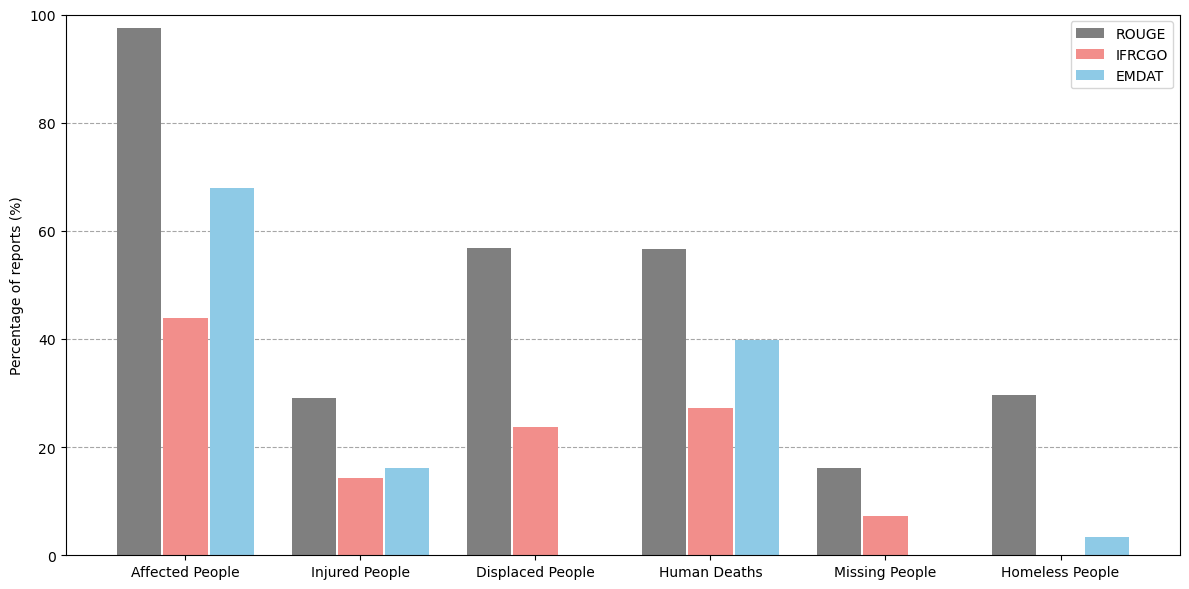

In [13]:
impact_types = list(mapping_impact_type.keys())
x = np.arange(len(impact_types))

# Plot sources in a fixed order when available in the new dictionary format
plot_sources = [s for s in ["ROUGE", "IFRCGO", "EMDAT"] if s in perc_report_with_impact]
width = 0.8 / max(len(plot_sources), 1)

fig, ax = plt.subplots(figsize=(12, 6))

# Colors aligned with the new source names
# colors = {
#     "ROUGE": "#cc2f2f",
#     "IFRCGO": "#5fbf84",
#     "EMDAT": "#5fa8d3",
# }

colors = {
    "ROUGE": "#d66a6a",
    "IFRCGO": "#54a77a",
    "EMDAT": "#4c78a8",
}

for i, source in enumerate(plot_sources):
    offset = (i - (len(plot_sources) - 1) / 2) * width
    bars = ax.bar(
        x + offset,
        perc_report_with_impact[source],
        width * 0.95,
        label=source,
        color=colors.get(source, "grey"),
    )

    # Add value labels above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

# Labels
ax.set_xticks(x)
ax.set_xticklabels(impact_types)
ax.set_ylabel("Percentage of reports (%)")
ax.legend()

for y in [20, 40, 60, 80]:
    ax.axhline(y=y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)

ax.set_ylim(0, 100)

plt.tight_layout()
# fig.savefig(path_save_fig / "percentage_events_quanti_impact.png", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "percentage_events_quanti_impact.svg", format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "percentage_events_quanti_impact.pdf", format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

## Bar Plot after event matching

In [16]:
nb_matched = {}

In [17]:
nb_matched = {}
nb_exact_match = {}
nb_no_match = {}
nb_no_external_impact = {}
df_matched_with_impact = {}

tolerance = 0.10

def compute_matching_metrics_from_linked_df(
    df_linked,
    source_name,
    value_col,
    impact_subtypes,
    tolerance=0.10,
    reference_col="ROUGE",
    compare_col="IFRCGO",
    compare_prefix=None,
 ):
    """
    Compute matching metrics per impact subtype from a linked dataframe.

    Expected columns in df_linked:
    - appealCode
    - impactSubtype
    - impactValue_final
    - external value column (value_col)
    - optional comparison column (compare_col), e.g. EMDAT vs IFRCGO in linked ALL
    """
    out_nb_matched = []
    out_nb_exact_match = []
    out_nb_no_external_impact = []
    out_df_matched_with_impact = pd.DataFrame()

    for impactSubtype in impact_subtypes:
        df_sub = df_linked.loc[df_linked["impactSubtype"] == impactSubtype].copy()

        n_before = len(df_sub)
        if value_col not in df_sub.columns:
            out_nb_matched.append(0)
            out_nb_exact_match.append(0)
            out_nb_no_external_impact.append(n_before)
            continue

        # Only compute ROUGE-vs-external rel_diff when both values exist
        df_sub = df_sub.dropna(subset=["impactValue_final", value_col])
        n_after = len(df_sub)

        if n_after == 0:
            out_nb_matched.append(0)
            out_nb_exact_match.append(0)
            out_nb_no_external_impact.append(n_before)
            continue

        # Loop over the reference columns
        for ref_col in reference_col :
            # Add selection of relevant columns
            if ref_col=="ROUGE" :
                col_impactValue = "impactValue_final"
            else :
                col_impactValue = source_cfg[ref_col]["value_col"]

            # External vs reference col
            df_sub[f"abs_diff_{ref_col}"] = (df_sub[col_impactValue] - df_sub[value_col]).abs()
            df_sub[f"rel_diff_{ref_col}"] = ((df_sub[col_impactValue] - df_sub[value_col])/ df_sub[value_col].replace(0, np.nan))
            df_sub[f"abs_rel_diff_{ref_col}"] = df_sub[f"rel_diff_{ref_col}"].abs()
            df_sub[f"{source_name}/{ref_col}"] = df_sub[value_col] / df_sub[col_impactValue].replace(
                0, np.nan
            )
            df_sub[f"{ref_col}/{source_name}"] = df_sub[col_impactValue] / df_sub[value_col].replace(
                0, np.nan
            )
            df_sub[f"match_{ref_col}"] = df_sub[f"abs_rel_diff_{ref_col}"] <= tolerance

            out_df_matched_with_impact = pd.concat(
                [out_df_matched_with_impact, df_sub],
                axis=0,
                ignore_index=True,
            )

            out_nb_no_external_impact.append(n_before - n_after)
            out_nb_matched.append(df_sub["appealCode"].nunique())
            out_nb_exact_match.append(df_sub.loc[df_sub[f"match_{ref_col}"], "appealCode"].nunique())

    return {
        "nb_matched": out_nb_matched,
        "nb_exact_match": out_nb_exact_match,
        "nb_no_external_impact": out_nb_no_external_impact,
        "df_matched_with_impact": out_df_matched_with_impact,
    }


# Run for linked IFRCGO and EMDAT using their standardized impact value columns
source_cfg = {
    "IFRCGO": {"linked_key": "IFRCGO", "value_col": "IFRCGO_impactValue"},
    "EMDAT": {"linked_key": "EMDAT", "value_col": "EMDAT_impactValue"},
    # "ROUGE" : {"linked_key": "ROUGE", "value_col": "impactValue_final"},
    # "ALL": {
    #     "linked_key": "ALL",
    #     "value_col": "EMDAT_impactValue",
    #     "compare_col": "IFRCGO_impactValue",
    #     "compare_prefix": "EMDAT_vs_IFRCGO",
    # },
}
for source_name, cfg in source_cfg.items():
    metrics = compute_matching_metrics_from_linked_df(
        df_linked=df_llm_all_geo_grp_linked["ALL"],
        source_name=source_name,
        value_col=cfg["value_col"],
        impact_subtypes=list(mapping_impact_type.keys()),
        tolerance=tolerance,
        reference_col=["ROUGE", "EMDAT"],
        compare_col=cfg.get("compare_col"),
        compare_prefix=cfg.get("compare_prefix"),
    )

    nb_matched[source_name] = metrics["nb_matched"]
    nb_exact_match[source_name] = metrics["nb_exact_match"]
    nb_no_external_impact[source_name] = metrics["nb_no_external_impact"]
    df_matched_with_impact[source_name] = metrics["df_matched_with_impact"]
    df_matched_with_impact["ALL"] = metrics["df_matched_with_impact"]

## Coefficient of variation 

In [18]:
df = df_llm_all_geo_grp_linked["ALL"][["impactSubtype","impactValue","EMDAT_impactValue","IFRCGO_impactValue",]].copy()

# Rename for convenience
df = df.rename(columns={"impactValue": "ROUGE", "EMDAT_impactValue": "EMDAT","IFRCGO_impactValue": "IFRCGO",})

# Keep only complete rows
df = df[df.impactSubtype.isin(impact_subtypes)]

# Replace the quantitative values of 0 with NaN to avoid issues in log scale plotting
for col in ["ROUGE", "EMDAT", "IFRCGO"]:
    df[col] = df[col].replace(0, np.nan)

In [19]:
sources = ["ROUGE", "EMDAT", "IFRCGO"]
complete_mask = df[sources].notna().all(axis=1)

# Mean/std/CV
df["mean"] = df[sources].mean(axis=1, skipna=True)
df["std"] = df[sources].std(axis=1, skipna=True)

# Avoid division by zero
df["cv"] = np.where(df["mean"] != 0, df["std"] / df["mean"], np.nan)

# Squared deviations
for s in sources:
    df[f"{s}_sqdev"] = (df[s] - df["mean"])**2

sqdev_cols = [f"{s}_sqdev" for s in sources]

# Total variance contribution
df["total_sqdev"] = df[sqdev_cols].sum(axis=1)

for s in sources:
    df[f"{s}_contrib"] = (df[f"{s}_sqdev"] / df["total_sqdev"])

# Dominant contributor
contrib_cols = [f"{s}_contrib" for s in sources]
df.loc[complete_mask, "dominant_source"] = (df.loc[complete_mask, contrib_cols].idxmax(axis=1).str.replace("_contrib", ""))

# df["dominant_source"] = (df[contrib_cols].idxmax(axis=1).str.replace("_contrib", ""))

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_21992\521365953.py:25: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df.loc[complete_mask, "dominant_source"] = (df.loc[complete_mask, contrib_cols].idxmax(axis=1).str.replace("_contrib", ""))


In [26]:
def get_missing_combo_color(row, combo_color_map):
    emdat_missing = pd.isna(row.get("EMDAT")) or row.get("EMDAT") == ""
    ifrc_missing = pd.isna(row.get("IFRCGO")) or row.get("IFRCGO") == ""

    # ROUGE + EMDAT only (IFRCGO missing)
    if not emdat_missing and ifrc_missing:
        return combo_color_map["ROUGE + EM-DAT"]

    # ROUGE + IFRCGO only (EMDAT missing)
    if not ifrc_missing and emdat_missing:
        return combo_color_map["ROUGE + IFRC GO"]

    # fallback (both present or both missing)
    return "#b0b0b0"

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_21992\1320491580.py:287: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


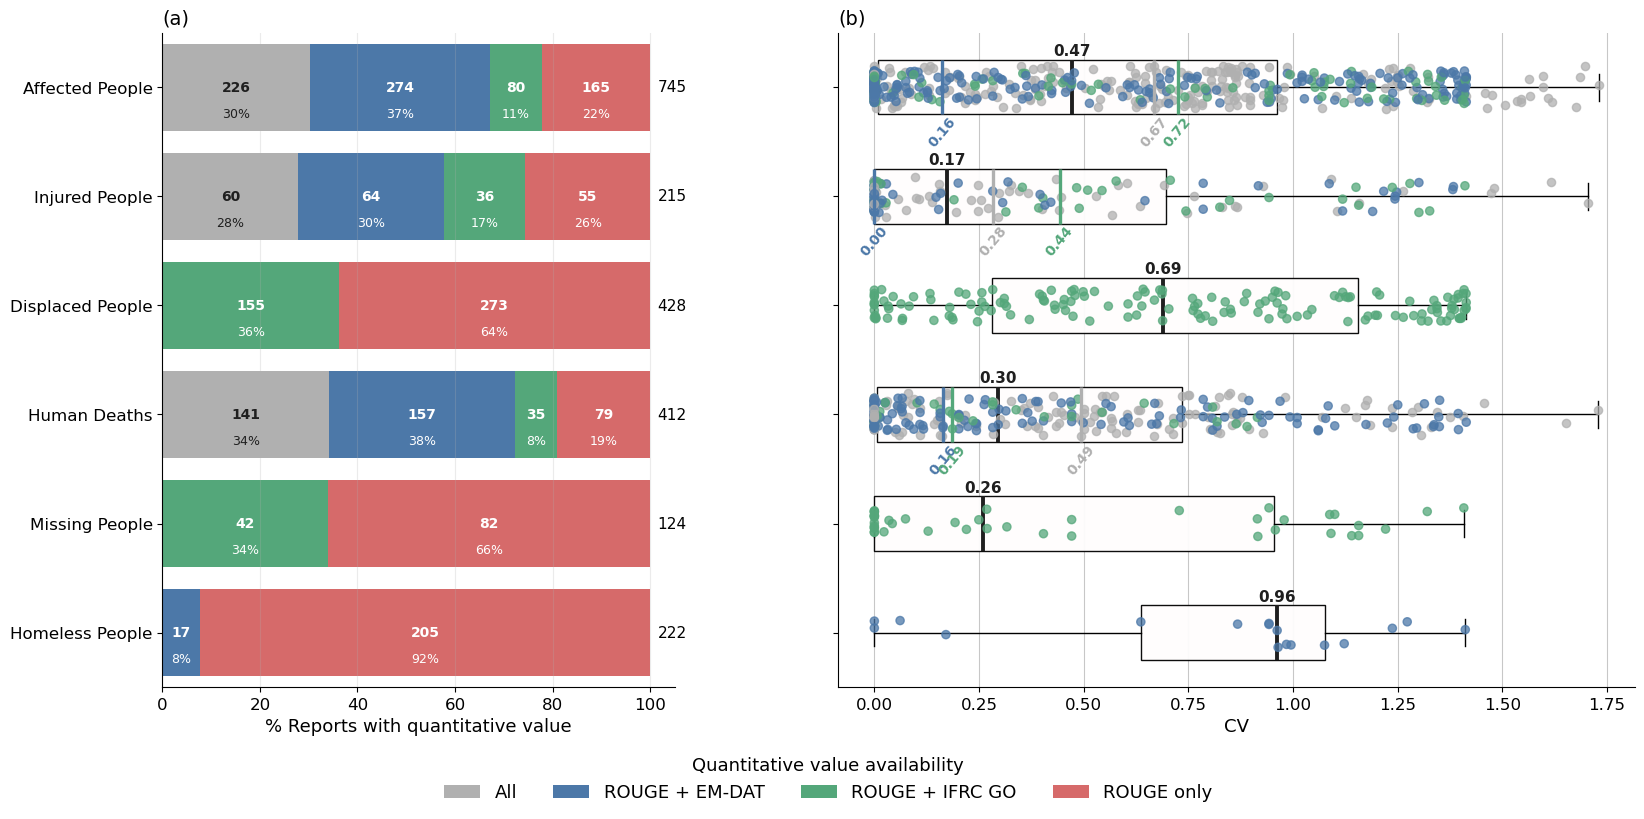

In [32]:
# Plot comparaison of quanti records and values
# ============================================================
# Typography
# ============================================================

title_fs = 14
label_fs = 13
tick_fs = 12
legend_fs = 13
count_fs = 11
annot_fs = 11

# ============================================================
# Colors
# ============================================================

combo_color_map = {
    "All": "#b0b0b0",            # light-medium gray (clean neutral)
    "ROUGE + EM-DAT": "#4c78a8",  # softened blue (less deep)
    "ROUGE + IFRC GO": "#54a77a", # softened green (balanced)
    "ROUGE only": "#d66a6a",     # softened red (less aggressive than #c53030)
}

# ============================================================
# Category ordering
# ============================================================

order = impact_subtypes[::-1]  # (df.groupby("impactSubtype")["cv"].median().sort_values().index)
categories = list(order)
df["impactSubtype"] = pd.Categorical(df["impactSubtype"], categories=categories, ordered=True)

# ============================================================
# Quantitative value availability by impact subtype
# ============================================================

presence = df[["ROUGE", "EMDAT", "IFRCGO"]].notna().copy()
presence["impactSubtype"] = df["impactSubtype"].astype(str)
presence = presence.dropna(subset=["impactSubtype"])

combo_masks = {
    "All": presence["ROUGE"] & presence["EMDAT"] & presence["IFRCGO"],
    "ROUGE + EM-DAT": presence["ROUGE"] & presence["EMDAT"] & ~presence["IFRCGO"],
    "ROUGE + IFRC GO": presence["ROUGE"] & ~presence["EMDAT"] & presence["IFRCGO"],
    "ROUGE only": presence["ROUGE"] & ~presence["EMDAT"] & ~presence["IFRCGO"],
}
combo_order = list(combo_masks.keys())

combo_labels = pd.Series(index=presence.index, dtype="object")
for label in combo_order:
    combo_labels.loc[combo_masks[label]] = label

df["availability_combo"] = combo_labels.reindex(df.index)

combo_counts_by_subtype = (
    presence.assign(combo=combo_labels)
    .dropna(subset=["combo"])
    .groupby(["impactSubtype", "combo"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=categories, columns=combo_order, fill_value=0)
)

# Convert counts to percentages so the x-axis is 0-100%.
combo_percent_by_subtype = combo_counts_by_subtype.div(combo_counts_by_subtype.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100

# ============================================================
# Figure
# ============================================================

fig, (ax_counts, ax) = plt.subplots(
    1,
    2,
    figsize=(19, 8.5),
    sharey=True,
    gridspec_kw={"width_ratios": [1.35, 2.1], "wspace": 0.25},
)

# ============================================================
# Left panel: quantitative-value counts per impact subtype
# ============================================================

left_accum = np.zeros(len(categories), dtype=float)
stack_styles = {
    "All": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
    "ROUGE + EM-DAT": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
    "ROUGE + IFRC GO": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
    "ROUGE only": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
}

for combo in combo_order:
    pct_values = combo_percent_by_subtype[combo].reindex(categories).values
    raw_values = combo_counts_by_subtype[combo].reindex(categories).values

    ax_counts.barh(
        categories,
        pct_values,
        left=left_accum,
        color=combo_color_map[combo],
        alpha=stack_styles[combo]["alpha"],
        label=combo,
    )

    # Exact counts inside each segment, where percentages used to be shown.
    for i, (count_value, left, pct_value, total) in enumerate(zip(raw_values, left_accum, pct_values, combo_counts_by_subtype.sum(axis=1).reindex(categories).values)):
        if count_value > 0 and total > 0:
            # Exact count (original)
            ax_counts.text(
                left + pct_value / 2,
                i,
                f"{int(count_value)}",
                ha="center",
                va="center",
                fontsize=count_fs - 1,
                color="white" if combo != "All" else "#1f1f1f",
                fontweight="bold",
            )
            # Percentage below the exact count
            ax_counts.text(
                left + pct_value / 2,
                i - 0.18,
                f"{pct_value:.0f}%",
                ha="center",
                va="top",
                fontsize=count_fs - 2,
                color="white" if combo != "All" else "#1f1f1f",
            )

    left_accum += pct_values

for i, total in enumerate(combo_counts_by_subtype.sum(axis=1).reindex(categories).values):
    if total > 0:
        ax_counts.text(
            101.5,
            i,
            f"{int(total)}",
            va="center",
            fontsize=count_fs,
        )

ax_counts.set_xlabel("% Reports with quantitative value", fontsize=label_fs)
ax_counts.set_ylabel("")
ax_counts.set_title("(a)", loc="left", fontsize=title_fs)
ax_counts.grid(axis="x", alpha=0.25)
ax_counts.set_xlim(0, 105)
ax_counts.spines["top"].set_visible(False)
ax_counts.spines["right"].set_visible(False)
ax_counts.tick_params(axis="both", labelsize=tick_fs)
ax_counts.legend(
    title="Quantitative value availability",
    bbox_to_anchor=(1.3, -0.2),
    loc="lower center",
    ncols=4,
    frameon=False,
    fontsize=legend_fs,
    title_fontsize=legend_fs,
)

# ============================================================
# Right panel: CV distribution
# ============================================================

boxplot_data = [df.loc[df["impactSubtype"] == cat, "cv"].dropna() for cat in categories]

bp = ax.boxplot(
    boxplot_data,
    vert=False,
    positions=np.arange(len(categories)),
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for patch in bp["boxes"]:
    patch.set_facecolor("#fffdfd")
    patch.set_alpha(0.95)
    patch.set_edgecolor("black")

# Emphasize the median with a darker, thicker line and annotate its value
for median_line, values, pos in zip(bp["medians"], boxplot_data, np.arange(len(categories))):
    median_value = float(np.nanmedian(values)) if len(values) > 0 else np.nan
    median_line.set_color("#1f1f1f")
    median_line.set_linewidth(2.8)
    if np.isfinite(median_value):
        ax.text(
            median_value,
            pos + 0.4,
            f"{median_value:.2f}",
            ha="center",
            va="top",
            rotation=0,
            fontsize=annot_fs,
            color="#1f1f1f",
            fontweight="bold",
            zorder=6,
        )

# Additional subset medians (only for categories quantified in all databases)
subset_median_categories = {"Affected People", "Injured People", "Human Deaths"}
subset_annot_combos = ["All", "ROUGE + EM-DAT", "ROUGE + IFRC GO", "ROUGE only"]

for pos, cat in enumerate(categories):
    if cat not in subset_median_categories:
        continue

    y_base = pos
    y_step = 0.12
    marker_half_height = 0.25

    for j, combo in enumerate(subset_annot_combos):
        med_vals = df.loc[
            (df["impactSubtype"] == cat) & (df["availability_combo"] == combo),
            "cv",
        ].dropna()

        if len(med_vals) == 0:
            continue

        med = float(np.nanmedian(med_vals))
        y = y_base# + j * y_step

        # Vertical marker line at subset median (same idea as boxplot median line)
        ax.vlines(
            med,
            y - marker_half_height,
            y + marker_half_height,
            color=combo_color_map[combo],
            linewidth=2.4,
            zorder=7,
        )

        # Numeric value above the median marker line
        ax.text(
            med,
            y - marker_half_height,
            f"{med:.2f}",
            ha="center",
            va="top",
            rotation=50,
            fontsize=annot_fs - 1,
            color=combo_color_map[combo],
            fontweight="bold",
            zorder=8,
        )

rng = np.random.default_rng(42)
y_map = {cat: i for i, cat in enumerate(categories)}

sub_missing = df[df["dominant_source"].isna()]
y_missing = np.array([y_map[v] for v in sub_missing["impactSubtype"]])
y_missing_jitter = y_missing + rng.uniform(-0.15, 0.15, len(y_missing))

colors_missing = sub_missing.apply(get_missing_combo_color, axis=1, combo_color_map=combo_color_map)
ax.scatter(
    sub_missing["cv"],
    y_missing_jitter,
    s=35,
    alpha=0.75,
    color=colors_missing,
    label="None",
    zorder=4,
)

for source in ["ROUGE", "EMDAT", "IFRCGO"]:
    sub = df[df["dominant_source"] == source]
    y = np.array([y_map[v] for v in sub["impactSubtype"]])
    y_jitter = y + rng.uniform(-0.20, 0.20, len(y))

    ax.scatter(
        sub["cv"],
        y_jitter,
        s=35,
        alpha=0.75,
        color=combo_color_map["All"],
        label=source,
        zorder=3,
    )

ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories, fontsize=label_fs)
ax.set_xlabel("CV", fontsize=label_fs)
ax.grid(axis="x", alpha=0.22, color="black")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", labelsize=tick_fs)
ax.tick_params(axis="y", labelsize=tick_fs)
ax.set_title("(b)", loc="left", fontsize=title_fs)
plt.tight_layout()

fig.savefig(path_save_fig / f"quantitative_perc_comparison_number_value.png",
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"quantitative_perc_comparison_number_value.svg",
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
plt.show()